# Underfitting, Overfitting & Regularization

The same story across three models: **linear regression → logistic regression → SVM**.

- **Underfit** — too simple, misses the pattern (bad on train *and* test).
- **Overfit** — too complex, memorizes noise (great on train, bad on test).
- **Regularization** — a dial to control complexity without changing the model.

What matters is always the **test** score — performance on unseen data.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
import warnings; warnings.filterwarnings("ignore")

---
# 1 · Linear Regression

Fitting a curve. Complexity = polynomial **degree**.

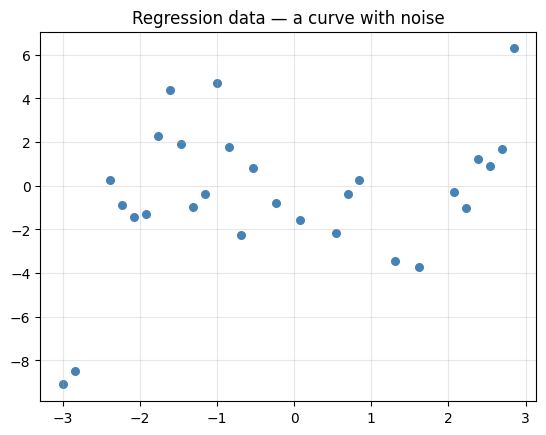

In [ ]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import r2_score

# a curvy dataset (with noise)
rng = np.random.default_rng(5)
x = np.linspace(-3, 3, 40)
y = 0.5*x**3 - 2*x + rng.normal(0, 2.0, 40)

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=1)

plt.scatter(x_train, y_train, color="steelblue", s=30)
plt.title("Regression data — a curve with noise"); 
plt.grid(alpha=0.3); 
plt.show()

### Underfit → good → overfit (degree 1, 4, 15)

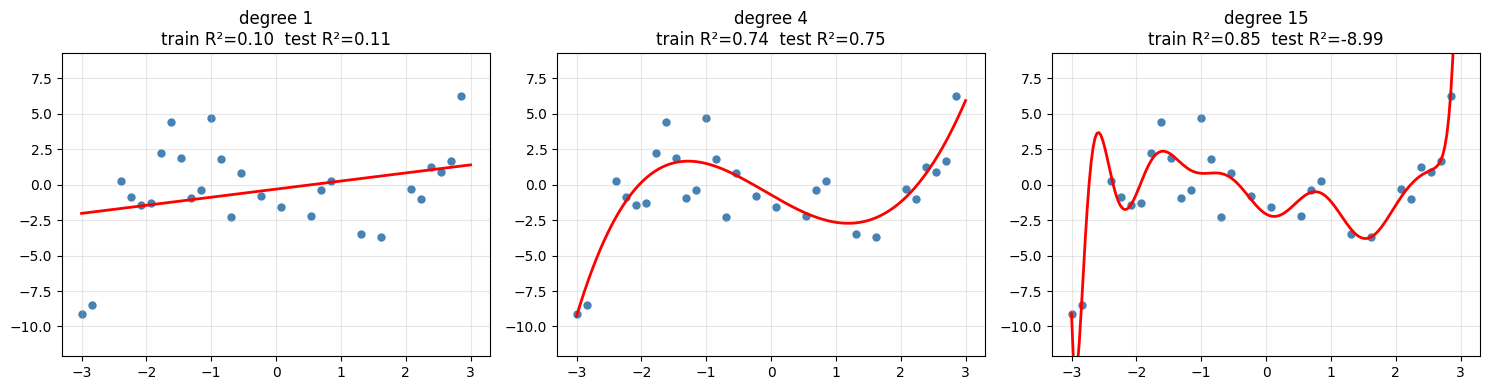

In [3]:
def reg_model(degree, alpha=None):
    steps = [PolynomialFeatures(degree), StandardScaler()]
    steps.append(Ridge(alpha=alpha) if alpha is not None else LinearRegression())
    return make_pipeline(*steps)

xs = np.linspace(-3, 3, 200)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, deg in zip(axes, [1, 4, 15]):
    m = reg_model(deg).fit(x_train.reshape(-1,1), y_train)
    tr = r2_score(y_train, m.predict(x_train.reshape(-1,1)))
    te = r2_score(y_test,  m.predict(x_test.reshape(-1,1)))
    ax.scatter(x_train, y_train, color="steelblue", s=25)
    ax.plot(xs, m.predict(xs.reshape(-1,1)), color="red", lw=2)
    ax.set_ylim(y.min()-3, y.max()+3)
    ax.set_title(f"degree {deg}\ntrain R²={tr:.2f}  test R²={te:.2f}")
    ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

Degree 1 underfits (both low), degree 4 fits well, degree 15 overfits (high train, **negative test**).

### Fix degree 15 with regularization (Ridge, strength = alpha)

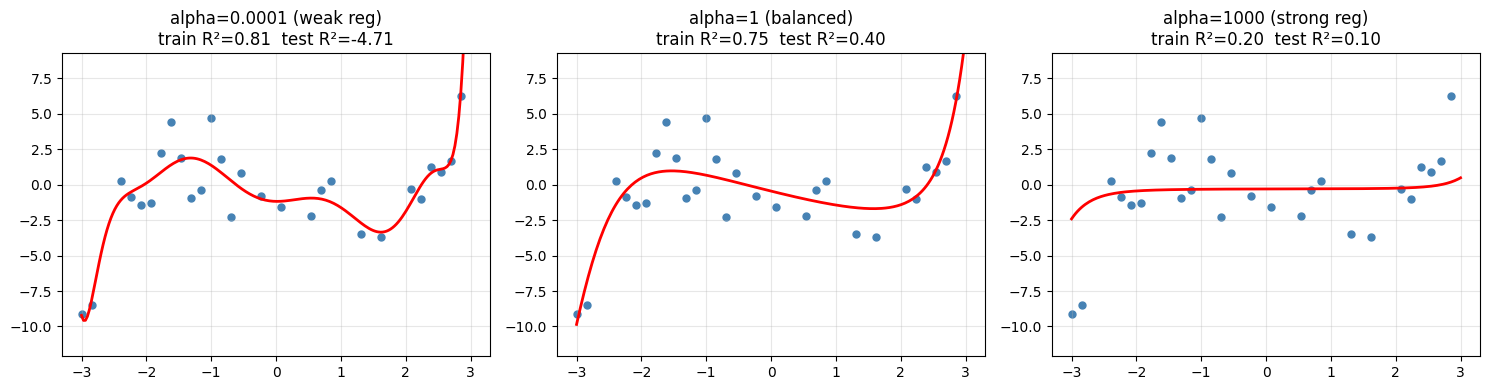

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, alpha in zip(axes, [0.0001, 1, 1000]):
    m = reg_model(15, alpha=alpha).fit(x_train.reshape(-1,1), y_train)
    tr = r2_score(y_train, m.predict(x_train.reshape(-1,1)))
    te = r2_score(y_test,  m.predict(x_test.reshape(-1,1)))
    ax.scatter(x_train, y_train, color="steelblue", s=25)
    ax.plot(xs, m.predict(xs.reshape(-1,1)), color="red", lw=2)
    ax.set_ylim(y.min()-3, y.max()+3)
    strength = {0.0001:"weak reg", 1:"balanced", 1000:"strong reg"}[alpha]
    ax.set_title(f"alpha={alpha} ({strength})\ntrain R²={tr:.2f}  test R²={te:.2f}")
    ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

Same degree-15 model, only `alpha` changed: weak reg still overfits, **balanced fixes it**, strong reg over-corrects into underfitting.

---
# 2 · Logistic Regression

Classification. Complexity = polynomial **degree**; regularization = **C** (small C = strong).

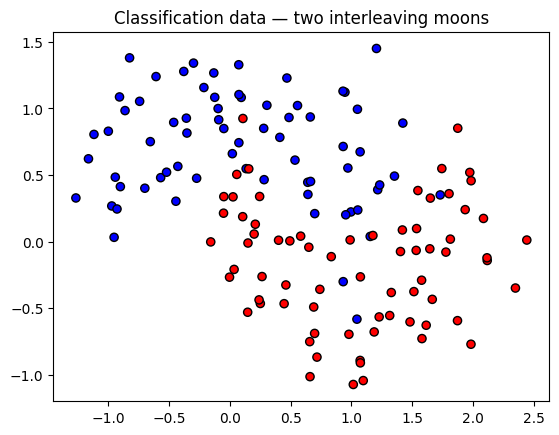

In [5]:
from sklearn.datasets import make_moons
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

Xm, ym = make_moons(n_samples=200, noise=0.30, random_state=3)
Xm_tr, Xm_te, ym_tr, ym_te = train_test_split(Xm, ym, test_size=0.3, random_state=1)

plt.scatter(Xm_tr[:,0], Xm_tr[:,1], c=ym_tr, cmap="bwr", edgecolor="k", s=35)
plt.title("Classification data — two interleaving moons"); plt.show()

In [6]:
def plot_clf(model, X, yv, ax, title):
    xx, yy = np.meshgrid(np.linspace(X[:,0].min()-.5, X[:,0].max()+.5, 300),
                         np.linspace(X[:,1].min()-.5, X[:,1].max()+.5, 300))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.25, cmap="bwr")
    ax.scatter(X[:,0], X[:,1], c=yv, cmap="bwr", edgecolor="k", s=22)
    ax.set_title(title); ax.set_xticks([]); ax.set_yticks([])

### Underfit → good → overfit (degree 1, 4, 15)

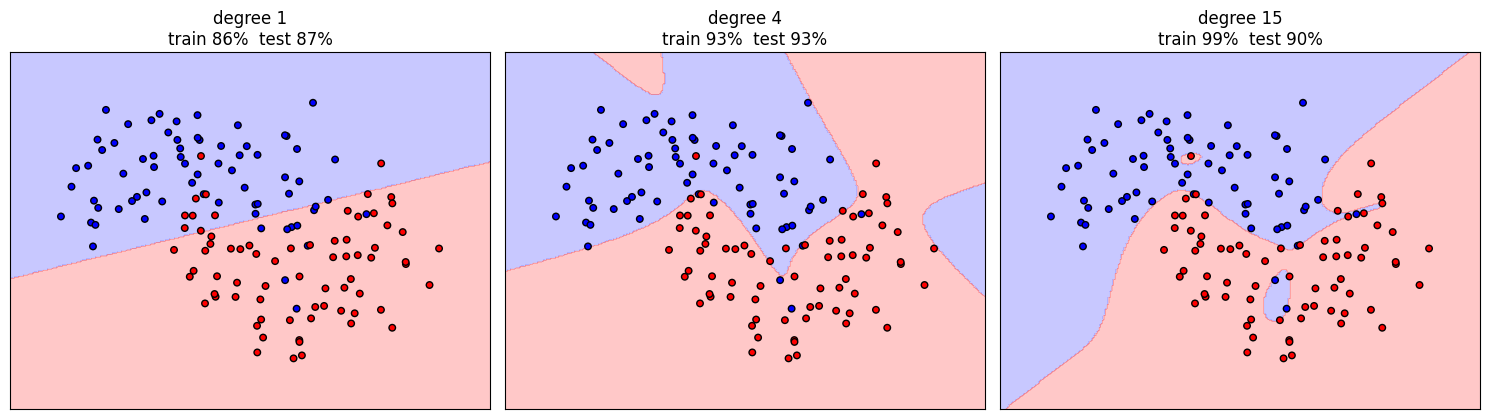

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.3))
for ax, deg in zip(axes, [1, 4, 15]):
    m = make_pipeline(PolynomialFeatures(deg), LogisticRegression(C=1e6, max_iter=5000))
    m.fit(Xm_tr, ym_tr)
    tr = accuracy_score(ym_tr, m.predict(Xm_tr))
    te = accuracy_score(ym_te, m.predict(Xm_te))
    plot_clf(m, Xm_tr, ym_tr, ax, f"degree {deg}\ntrain {tr:.0%}  test {te:.0%}")
plt.tight_layout(); plt.show()

Degree 1 underfits (straight line), degree 4 fits the moons, degree 15 overfits (islands chasing noise; train up, test down).

### Fix degree 15 with regularization (C)

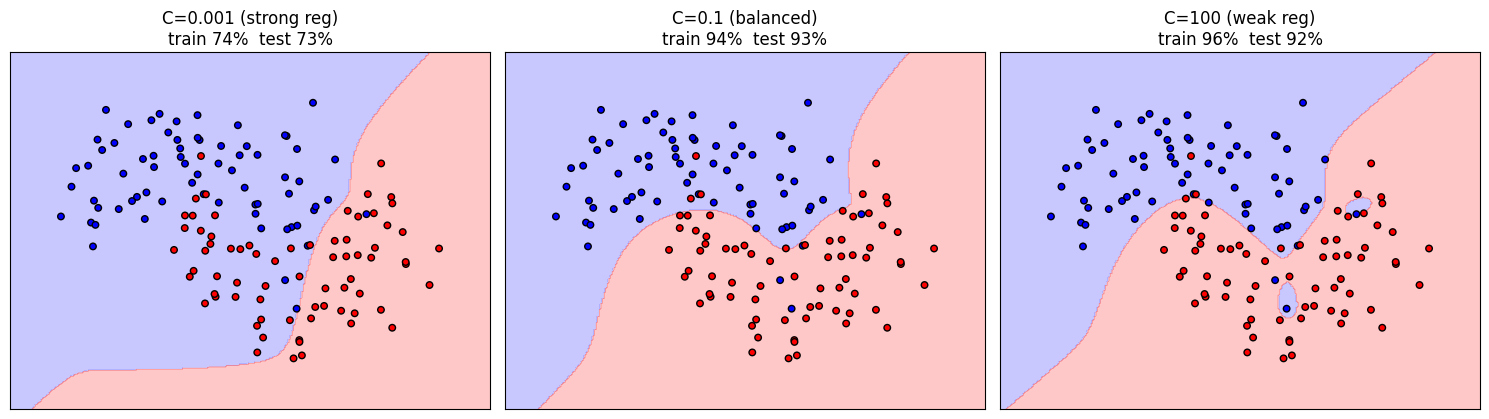

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.3))
for ax, C in zip(axes, [0.001, 0.1, 100]):
    m = make_pipeline(PolynomialFeatures(15), LogisticRegression(C=C, max_iter=5000))
    m.fit(Xm_tr, ym_tr)
    tr = accuracy_score(ym_tr, m.predict(Xm_tr))
    te = accuracy_score(ym_te, m.predict(Xm_te))
    strength = {0.001:"strong reg", 0.1:"balanced", 100:"weak reg"}[C]
    plot_clf(m, Xm_tr, ym_tr, ax, f"C={C} ({strength})\ntrain {tr:.0%}  test {te:.0%}")
plt.tight_layout(); plt.show()

Same degree-15 model, only `C` changed: strong reg underfits, **balanced fixes it**, weak reg overfits again. (Note C is inverse: small C = strong regularization.)

---
# 3 · SVM

Same idea. Complexity = **gamma** (RBF kernel); regularization = **C**.

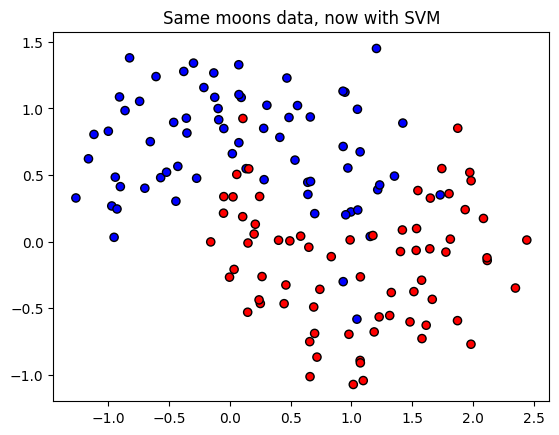

In [9]:
from sklearn.svm import SVC

# reuse the moons data
plt.scatter(Xm_tr[:,0], Xm_tr[:,1], c=ym_tr, cmap="bwr", edgecolor="k", s=35)
plt.title("Same moons data, now with SVM"); plt.show()

### Underfit → good → overfit (gamma controls boundary wiggliness)

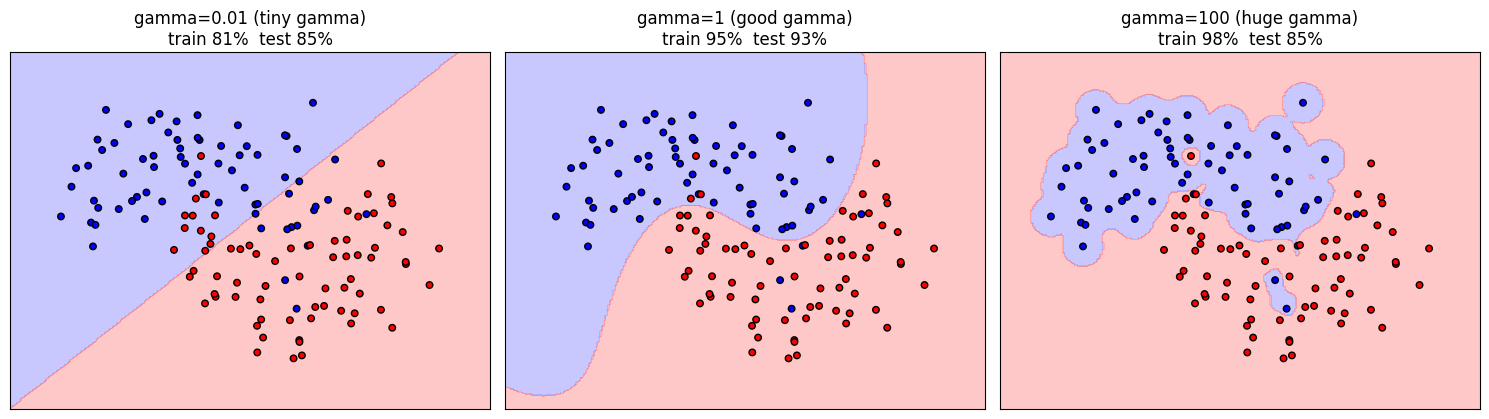

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.3))
for ax, gamma in zip(axes, [0.01, 1, 100]):
    m = SVC(kernel="rbf", gamma=gamma, C=1).fit(Xm_tr, ym_tr)
    tr = accuracy_score(ym_tr, m.predict(Xm_tr))
    te = accuracy_score(ym_te, m.predict(Xm_te))
    label = {0.01:"tiny gamma", 1:"good gamma", 100:"huge gamma"}[gamma]
    plot_clf(m, Xm_tr, ym_tr, ax, f"gamma={gamma} ({label})\ntrain {tr:.0%}  test {te:.0%}")
plt.tight_layout(); plt.show()

Tiny gamma underfits (too smooth), good gamma fits, huge gamma overfits (tight bubbles around points; train up, test down).

### Fix high gamma with regularization (C)

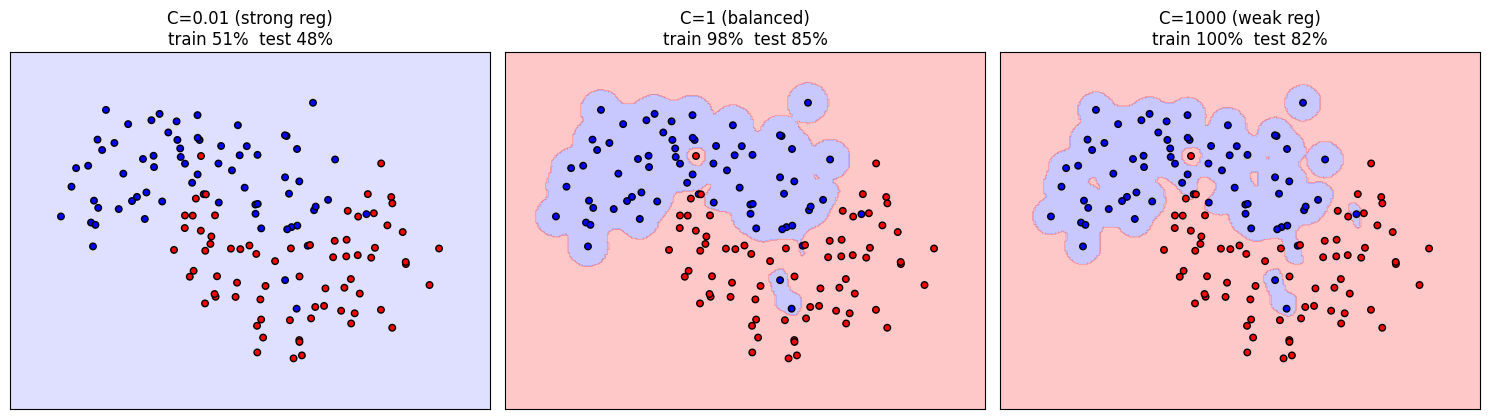

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.3))
for ax, C in zip(axes, [0.01, 1, 1000]):
    m = SVC(kernel="rbf", gamma=100, C=C).fit(Xm_tr, ym_tr)   # gamma fixed high (overfitting)
    tr = accuracy_score(ym_tr, m.predict(Xm_tr))
    te = accuracy_score(ym_te, m.predict(Xm_te))
    strength = {0.01:"strong reg", 1:"balanced", 1000:"weak reg"}[C]
    plot_clf(m, Xm_tr, ym_tr, ax, f"C={C} ({strength})\ntrain {tr:.0%}  test {te:.0%}")
plt.tight_layout(); plt.show()

With gamma stuck high, `C` still helps: strong reg (small C) smooths the boundary and lifts test accuracy; weak reg lets it overfit.

---
# Summary

| Model | Complexity knob | Regularization |
|---|---|---|
| Linear regression | polynomial degree | Ridge `alpha` (big = strong) |
| Logistic regression | polynomial degree | `C` (small = strong) |
| SVM | `gamma` | `C` (small = strong) |

Same lesson everywhere: **too simple underfits, too complex overfits, regularization dials in the balance.** Always judge on the **test** set.